In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [28]:
path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
HI_dmax = xr.open_dataset(path+'dailymax_HI.nc')
ATL3 = xr.open_dataset(path+'ATL3.nc')
ONI = xr.open_dataset(path+'ONI.nc')
CANI_EANI = xr.open_dataset(path+'CANI_EANI.nc')
HI_dmax_month_anom = xr.open_dataset(path+'HI_dmax_month_anom.nc')

In [29]:
RH = xr.open_dataset(path+'RHanom_during_HIdmax.nc')
T  = xr.open_dataset(path+'Tanom_during_HIdmax.nc')
U  = xr.open_dataset(path+'U_Hidmax_anom.nc')
V  = xr.open_dataset(path+'V_Hidmax_anom.nc')
MFD = xr.open_dataset(path+'MFD_HIdmax_anom.nc')

In [30]:
idate = '1940-01-01'
fdate = '2025-12-31'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3'].sel(valid_time=slice(idate, fdate))
ONI = ONI['ONI'].sel(valid_time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))
RH = RH['RHanom_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['Tanom_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U10_HIdmax_anom'].sel(time=slice(idate, fdate))
V = V['V10_HIdmax_anom'].sel(time=slice(idate, fdate))
CANI = CANI_EANI['CANI'].sel(time=slice(idate, fdate))
EANI = CANI_EANI['EANI'].sel(time=slice(idate, fdate))
MFD = MFD['MFD_HIdmax_anom'].sel(time=slice(idate, fdate))

In [31]:
U

<xarray.DataArray 'U10_HIdmax_anom' (time: 16436, latitude: 82, longitude: 121)> Size: 652MB
[163077992 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 131kB 1981-01-01 1981-01-02 ... 2025-12-31
    month      (time) int64 131kB ...
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [32]:
V

<xarray.DataArray 'V10_HIdmax_anom' (time: 16436, latitude: 82, longitude: 121)> Size: 652MB
[163077992 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 131kB 1981-01-01 1981-01-02 ... 2025-12-31
    month      (time) int64 131kB ...
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

In [33]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 1GB
Dimensions:          (latitude: 82, longitude: 121, time: 16436)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 131kB 1981-01-01 ... 2025-12-31
    month            (time) int64 131kB 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
Data variables:
    U10_HIdmax_anom  (time, latitude, longitude) float32 652MB ...
    V10_HIdmax_anom  (time, latitude, longitude) float32 652MB ...

# monthly means

In [34]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)
meMFD = me_mean(MFD)

In [35]:
meMFD

<xarray.DataArray 'MFD_HIdmax_anom' (time: 1032, latitude: 82, longitude: 121)> Size: 41MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1032, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2025-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Attributes:
    long_name:   latitude
    short_name:  lat
    units:       degrees_north

# ERS selection

In [36]:
ERS = [4, 5, 6, 7]
ERS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(ERS), drop=True)
ERS_ATL3 = ATL3.where(ATL3.valid_time.dt.month.isin(ERS), drop=True)
ERS_ONI = ONI.where(ONI.valid_time.dt.month.isin(ERS), drop=True)
ERS_RH = meRH.where(meRH.time.dt.month.isin(ERS), drop=True)
ERS_T = meT.where(meT.time.dt.month.isin(ERS), drop=True)
ERS_UV = meUV.where(meUV.time.dt.month.isin(ERS), drop=True)
ERS_CANI = CANI.where(CANI.time.dt.month.isin(ERS), drop=True)
ERS_EANI = EANI.where(EANI.time.dt.month.isin(ERS), drop=True)
ERS_MFD = meMFD.where(meMFD.time.dt.month.isin(ERS), drop=True)

# phase selection

In [37]:
def niño(ds):
    return ds >= 0.5


def niña(ds):
    return ds <= -0.5


def neutral(ds):
    return ((ds > -0.5) & (ds < 0.5) )

## idx season mean every year

In [38]:
ERS_CANI

<xarray.DataArray 'CANI' (time: 344)> Size: 3kB
array([ 1.52982682e+00,  1.47926273e+00,  1.14103968e+00,  6.06841407e-01,
        2.51787464e-01, -1.58037808e-01, -9.61348472e-02,  2.01534757e-01,
       -5.13731237e-02, -1.33798006e-01, -1.61672850e-01, -3.97662807e-01,
       -1.20654040e+00, -1.05591026e+00, -8.23364398e-01, -1.11740277e-01,
        1.35330193e+00,  1.52292415e+00,  1.27303546e+00,  9.35483464e-01,
        1.19680482e+00,  1.43639616e+00,  7.37487370e-01, -7.70046919e-01,
        1.11656054e+00,  3.36986872e-02, -9.15718167e-01, -1.21525241e+00,
        9.05955603e-01,  1.10330867e+00,  9.93322345e-01,  8.97207438e-01,
        5.19882259e-01,  3.01050418e-01, -1.31208821e-02,  2.46013688e-01,
        7.91079522e-01,  5.76895786e-01,  1.14187198e+00,  1.67960597e+00,
        7.22129592e-01,  2.81408360e-01,  6.15534431e-02, -2.22797478e-03,
       -1.40346812e+00, -9.54094675e-01, -3.03141254e-01, -7.57724272e-02,
        9.19385257e-01,  8.67136025e-01,  8.20401584e-01,  8.57545901e-01,
        3.72806729e-02, -2.16504175e-01, -4.47446875e-02,  2.44786533e-01,
       -8.57951927e-01, -9.48989147e-01, -8.60228289e-01, -9.89876758e-01,
       -4.89985150e-01, -3.17087835e-01, -1.82166932e-01, -1.57476314e-01,
       -1.43169422e+00, -1.30057979e+00, -9.94913680e-01, -6.96930773e-01,
       -3.74731701e-01, -2.70270868e-01, -2.71898283e-01, -6.05824418e-01,
       -3.70376986e-01, -1.14896694e+00, -1.79354241e+00, -2.36701576e+00,
       -1.05031035e-01, -2.95500002e-01, -2.96973554e-01, -2.52199205e-01,
...
        2.76891724e-02,  3.22423646e-01,  4.84612888e-01,  6.64852790e-01,
        1.76068750e-01, -1.13442793e-01,  1.73524952e-02,  4.83729632e-03,
        5.04703086e-01,  8.87549218e-01,  1.11218302e+00,  1.34249151e+00,
        2.26682133e-01,  7.57298442e-01,  1.00595560e+00,  7.48154219e-01,
        1.36686618e+00,  1.89062837e+00,  2.26114312e+00,  2.12054826e+00,
        6.68556575e-01,  7.23815870e-01,  4.36058835e-01,  3.17856955e-01,
       -1.81639752e+00, -1.73816045e+00, -1.68463399e+00, -1.43502591e+00,
       -5.22864318e-01, -3.41108095e-01, -3.22852009e-01, -2.11631310e-01,
       -9.04816055e-01, -3.18345038e-01, -3.50581333e-02, -1.94392729e-01,
       -1.12018704e+00, -9.48177209e-01, -1.00294318e+00, -1.09510532e+00,
        1.18550714e-01, -1.13878890e-01, -2.24449694e-01, -1.23387477e-01,
        1.99626471e-01,  4.66904410e-01,  5.58409442e-01,  4.66235780e-01,
       -1.31159429e+00, -9.46071793e-01, -7.61853886e-01, -4.99541853e-01,
        1.11896938e+00,  8.99325730e-01,  2.91927318e-01, -1.47436812e-01,
        1.78843378e+00,  1.25240988e+00,  8.33062834e-01,  4.01273151e-01,
       -1.03174079e+00, -5.83140822e-01,  2.17388492e-01,  1.21583332e+00,
        1.64552346e-01,  1.94608868e-01,  4.27336023e-01,  4.15238173e-01,
        7.12308713e-01,  8.06774930e-01,  8.32244906e-01,  7.19508441e-01,
        3.54137693e+00,  3.25028025e+00,  2.11928235e+00,  6.72672091e-01,
        6.92706294e-01,  3.36741473e-01, -2.43917752e-01, -6.72557036e-01])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1940-04-01 1940-05-01 ... 2025-07-01
Attributes:
    description:  Central Atlantic Niño Index. PCs scaled by STD. Rolling mea...

In [39]:
ERS_CANI_y = ERS_CANI.resample(time='YE').mean()
ERS_EANI_y = ERS_EANI.resample(time='YE').mean()
ERS_ATL3_y = ERS_ATL3.resample(valid_time='YE').mean()
ERS_ONI_y = ERS_ONI.resample(valid_time='YE').mean()

## list of years

In [40]:
# o in the end is for niño, a is for niña, n for neutral
CANo = ERS_CANI_y.time.dt.year.where(niño(ERS_CANI_y), drop=True).rename('Warm CAN')
CANa = ERS_CANI_y.time.dt.year.where(niña(ERS_CANI_y), drop=True).rename('Cold CAN')
CANn = ERS_CANI_y.time.dt.year.where(neutral(ERS_CANI_y), drop=True).rename('Neutral CAN')

EANo = ERS_EANI_y.time.dt.year.where(niño(ERS_EANI_y), drop=True).rename('Warm EAN')
EANa = ERS_EANI_y.time.dt.year.where(niña(ERS_EANI_y), drop=True).rename('Cold EAN')
EANn = ERS_EANI_y.time.dt.year.where(neutral(ERS_EANI_y), drop=True).rename('Neutral EAN')

ATL3a= ERS_ATL3_y.valid_time.dt.year.where(niña(ERS_ATL3_y), drop=True).rename('Cold ATL3')
ATL3o= ERS_ATL3_y.valid_time.dt.year.where(niño(ERS_ATL3_y), drop=True).rename('Warm ATL3')
ATL3n= ERS_ATL3_y.valid_time.dt.year.where(neutral(ERS_ATL3_y), drop=True).rename('Neutral ATL3')

ONIo = ERS_ONI_y.valid_time.dt.year.where(niño(ERS_ONI_y), drop=True).rename('Warm ONI')
ONIa = ERS_ONI_y.valid_time.dt.year.where(niña(ERS_ONI_y), drop=True).rename('Cold ONI')
ONIn = ERS_ONI_y.valid_time.dt.year.where(neutral(ERS_ONI_y), drop=True).rename('Neutral ONI')

### lists

#### Atlantic Niño years

In [41]:
CANo

<xarray.DataArray 'Warm CAN' (time: 27)> Size: 216B
array([1940., 1944., 1945., 1947., 1949., 1952., 1961., 1962., 1963.,
       1964., 1966., 1969., 1971., 1973., 1984., 1988., 1995., 1996.,
       1998., 2008., 2009., 2010., 2011., 2019., 2020., 2023., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 216B 1940-12-31 1944-12-31 ... 2024-12-31

In [42]:
EANo

<xarray.DataArray 'Warm EAN' (time: 24)> Size: 192B
array([1944., 1945., 1949., 1950., 1952., 1961., 1963., 1966., 1969.,
       1973., 1984., 1987., 1988., 1991., 1995., 1996., 1998., 1999.,
       2007., 2008., 2020., 2021., 2023., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 192B 1944-12-31 1945-12-31 ... 2024-12-31

In [43]:
ATL3o

<xarray.DataArray 'Warm ATL3' (valid_time: 14)> Size: 112B
array([1963., 1984., 1988., 1991., 1995., 1996., 1998., 1999., 2008.,
       2009., 2010., 2021., 2023., 2024.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 112B 1963-12-31 ... 2024-12-31
Attributes:
    long_name:      time
    standard_name:  time

#### Atlantic Niña years

In [44]:
CANa

<xarray.DataArray 'Cold CAN' (time: 23)> Size: 184B
array([1943., 1951., 1954., 1956., 1958., 1972., 1976., 1977., 1978.,
       1979., 1980., 1981., 1983., 1990., 1992., 1993., 1994., 1997.,
       2002., 2004., 2012., 2015., 2018.])
Coordinates:
  * time     (time) datetime64[ns] 184B 1943-12-31 1951-12-31 ... 2018-12-31

In [45]:
EANa

<xarray.DataArray 'Cold EAN' (time: 25)> Size: 200B
array([1943., 1954., 1956., 1957., 1958., 1972., 1975., 1976., 1977.,
       1978., 1980., 1982., 1985., 1990., 1992., 1993., 1994., 1997.,
       2004., 2005., 2012., 2013., 2014., 2015., 2018.])
Coordinates:
  * time     (time) datetime64[ns] 200B 1943-12-31 1954-12-31 ... 2018-12-31

In [46]:
ATL3a

<xarray.DataArray 'Cold ATL3' (valid_time: 11)> Size: 88B
array([1943., 1948., 1954., 1956., 1958., 1976., 1977., 1978., 1983.,
       1992., 1997.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 88B 1943-12-31 ... 1997-12-31
Attributes:
    long_name:      time
    standard_name:  time

#### ENSO years

In [47]:
ONIo

<xarray.DataArray 'Warm ONI' (valid_time: 19)> Size: 152B
array([1940., 1941., 1953., 1957., 1958., 1959., 1966., 1969., 1982.,
       1983., 1987., 1992., 1993., 1997., 1998., 2015., 2016., 2019.,
       2024.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 152B 1940-12-31 ... 2024-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [48]:
ONIa

<xarray.DataArray 'Cold ONI' (valid_time: 21)> Size: 168B
array([1943., 1950., 1955., 1956., 1962., 1964., 1971., 1974., 1975.,
       1976., 1981., 1984., 1985., 1988., 1989., 1996., 1999., 2000.,
       2008., 2011., 2022.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 168B 1943-12-31 ... 2022-12-31
Attributes:
    long_name:      time
    standard_name:  time

#### Neutral

In [49]:
CANn

<xarray.DataArray 'Neutral CAN' (time: 36)> Size: 288B
array([1941., 1942., 1946., 1948., 1950., 1953., 1955., 1957., 1959.,
       1960., 1965., 1967., 1968., 1970., 1974., 1975., 1982., 1985.,
       1986., 1987., 1989., 1991., 1999., 2000., 2001., 2003., 2005.,
       2006., 2007., 2013., 2014., 2016., 2017., 2021., 2022., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 288B 1941-12-31 1942-12-31 ... 2025-12-31

In [50]:
EANn

<xarray.DataArray 'Neutral EAN' (time: 37)> Size: 296B
array([1940., 1941., 1942., 1946., 1947., 1948., 1951., 1953., 1955.,
       1959., 1960., 1962., 1964., 1965., 1967., 1968., 1970., 1971.,
       1974., 1979., 1981., 1983., 1986., 1989., 2000., 2001., 2002.,
       2003., 2006., 2009., 2010., 2011., 2016., 2017., 2019., 2022.,
       2025.])
Coordinates:
  * time     (time) datetime64[ns] 296B 1940-12-31 1941-12-31 ... 2025-12-31

In [51]:
ATL3n

<xarray.DataArray 'Neutral ATL3' (valid_time: 61)> Size: 488B
array([1940., 1941., 1942., 1944., 1945., 1946., 1947., 1949., 1950.,
       1951., 1952., 1953., 1955., 1957., 1959., 1960., 1961., 1962.,
       1964., 1965., 1966., 1967., 1968., 1969., 1970., 1971., 1972.,
       1973., 1974., 1975., 1979., 1980., 1981., 1982., 1985., 1986.,
       1987., 1989., 1990., 1993., 1994., 2000., 2001., 2002., 2003.,
       2004., 2005., 2006., 2007., 2011., 2012., 2013., 2014., 2015.,
       2016., 2017., 2018., 2019., 2020., 2022., 2025.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 488B 1940-12-31 ... 2025-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [52]:
ONIn

<xarray.DataArray 'Neutral ONI' (valid_time: 46)> Size: 368B
array([1942., 1944., 1945., 1946., 1947., 1948., 1949., 1951., 1952.,
       1954., 1960., 1961., 1963., 1965., 1967., 1968., 1970., 1972.,
       1973., 1977., 1978., 1979., 1980., 1986., 1990., 1991., 1994.,
       1995., 2001., 2002., 2003., 2004., 2005., 2006., 2007., 2009.,
       2010., 2012., 2013., 2014., 2017., 2018., 2020., 2021., 2023.,
       2025.])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 368B 1942-12-31 ... 2025-12-31
Attributes:
    long_name:      time
    standard_name:  time

## select anomalies

In [53]:
indices = [CANo, CANn, CANa, EANo, EANn, EANa, ATL3o, ATL3n, ATL3a, ONIo, ONIn, ONIa]
ERS_HI_oan = []
ERS_RH_oan = []
ERS_T_oan = []
ERS_UV_oan = []
ERS_MFD_oan = []

for i in indices:
    ERS_HI_oan.append(ERS_HI_dmax_anom.where(ERS_HI_dmax_anom.time.dt.year.isin(i.values), drop=True).rename(i.name))
    ERS_RH_oan.append(ERS_RH.where(ERS_RH.time.dt.year.isin(i.values), drop=True).rename(i.name))
    ERS_T_oan.append(ERS_T.where(ERS_T.time.dt.year.isin(i.values), drop=True).rename(i.name))
    ERS_MFD_oan.append(ERS_MFD.where(ERS_MFD.time.dt.year.isin(i.values), drop=True).rename(i.name))
    ERS_UV_oan.append(ERS_UV.where(ERS_UV.time.dt.year.isin(i.values), drop=True).rename({'U10_HIdmax_anom': i.name+'_U', 'V10_HIdmax_anom': i.name+'_V'}))

# Sig test

In [68]:
def xr_t_test(neutralds, anomds, dim='time'):

    stats_func = lambda x, y: stats.ttest_ind(x, y, axis=-1, equal_var=True)
    t, p = xr.apply_ufunc(stats_func, neutralds, anomds, 
                          input_core_dims=[[dim], [dim]],
                          output_core_dims=[[],[]],
                          vectorize=True, exclude_dims=set([dim])
                          )
    t_da = xr.DataArray(t, coords={'longitude': neutralds.longitude, 'latitude': neutralds.latitude}, name='t'+t.name[-3:])
    p_da = xr.DataArray(p, coords=t_da.coords, name="p"+t.name[-3:])

    stats_da = xr.merge([t_da, p_da])
    
    return stats_da

In [69]:
warms = ERS_HI_oan[0::3]
colds = ERS_HI_oan[2::3]
neutrals = ERS_HI_oan[1::3]

In [70]:
warm_stats = []
for i in range(4):
    warm_stats.append(xr_t_test(neutrals[i], warms[i]))

In [71]:
cold_stats = []
for i in range(4):
    cold_stats.append(xr_t_test(neutrals[i], colds[i]))

# phase plotting

### HI and UV

In [54]:
ERS_HI_oan_me = []
ERS_UV_oan_me = []
for i in ERS_HI_oan:
    ERS_HI_oan_me.append(i.mean('time'))
for i in ERS_UV_oan:
    ERS_UV_oan_me.append(i.mean('time'))

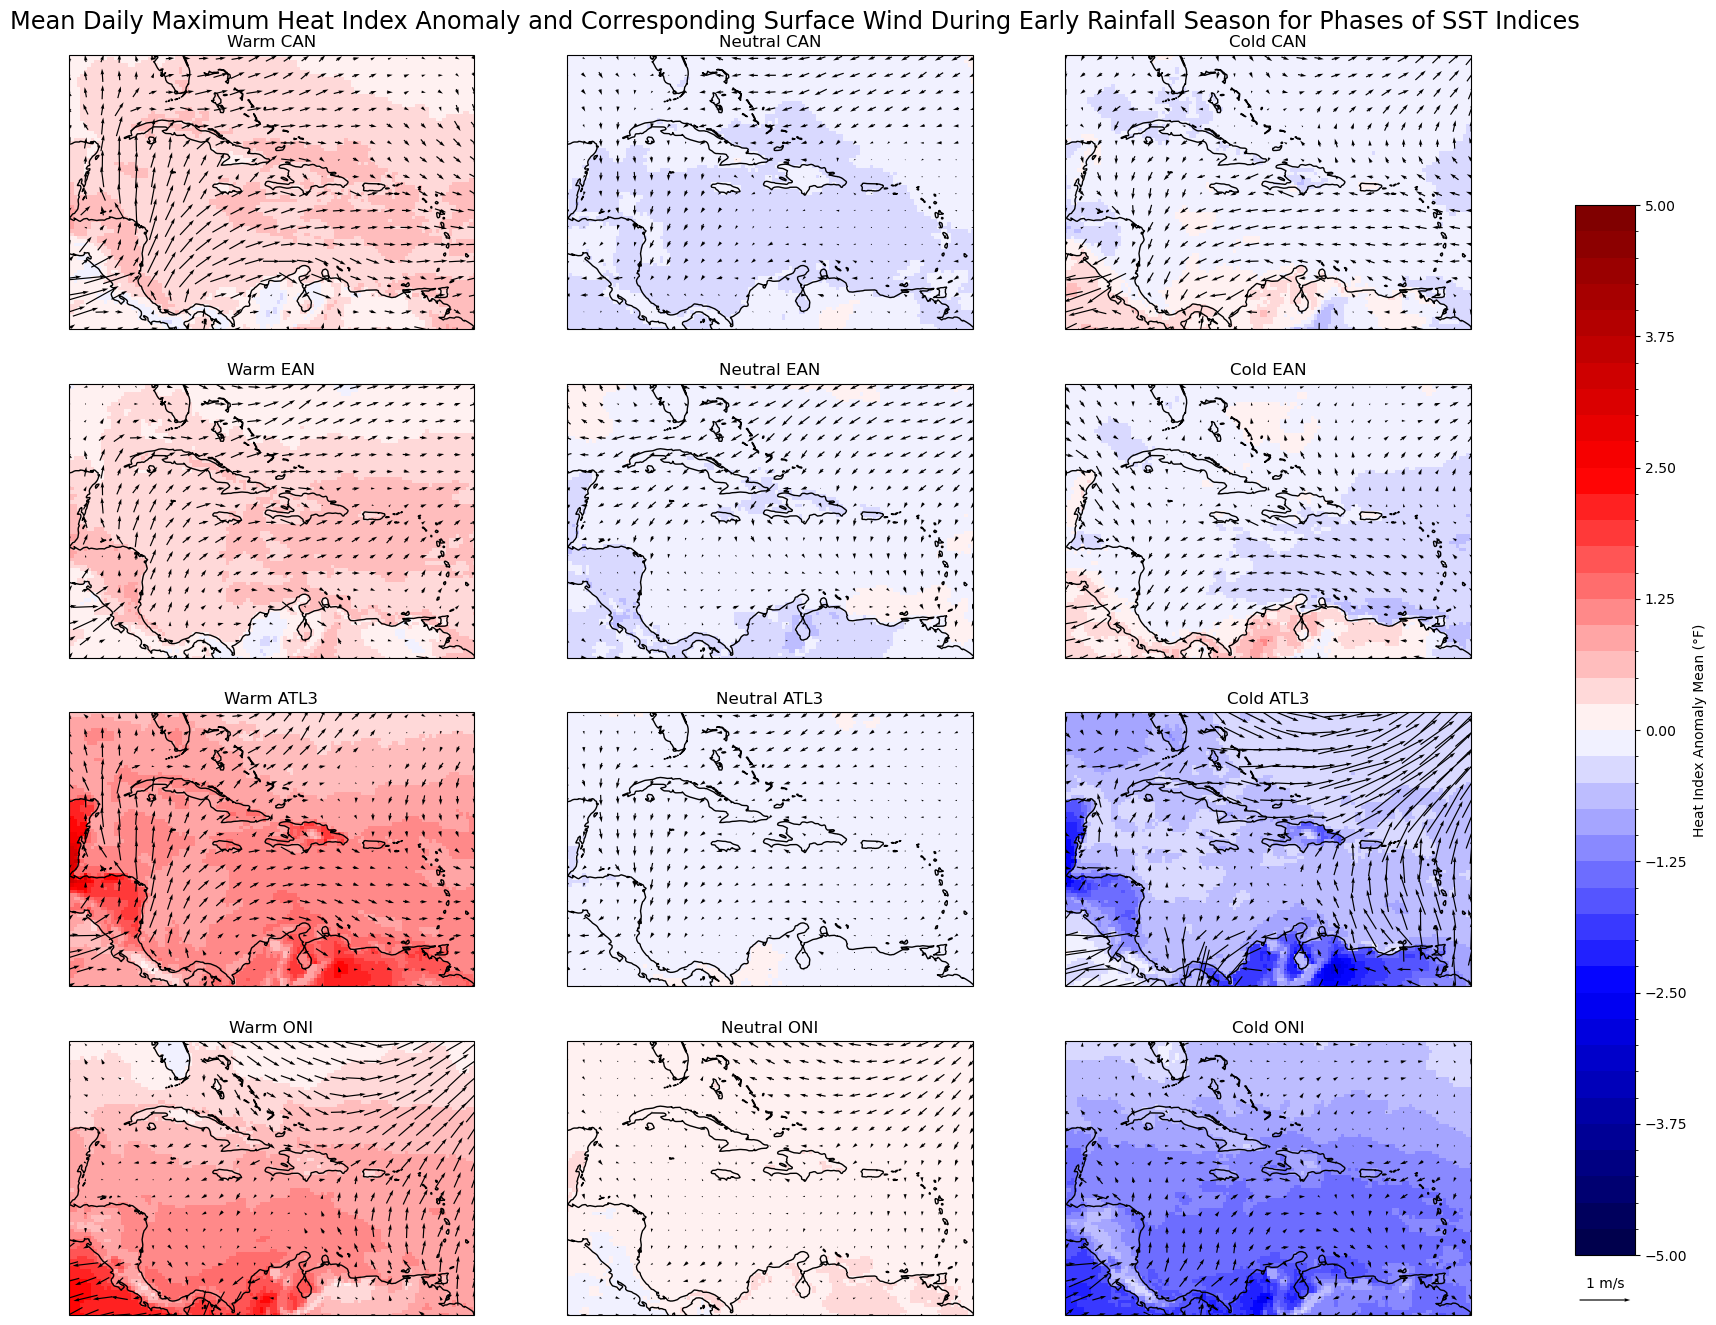

In [63]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)
flat_axes = axes.flatten()

for ax_i, (da, UVds) in enumerate(zip(ERS_HI_oan_me, ERS_UV_oan_me)):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-5, 5.25, 0.25), transform=ccrs.PlateCarree(), colors='seismic')

    U_var = [var for var in UVds.data_vars if var.endswith('U')][0]
    V_var = [var for var in UVds.data_vars if var.endswith('V')][0]

    UV_coarse = UVds.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
    quiver_obj = UV_coarse.plot.quiver(ax=ax, x='longitude', y='latitude', u=U_var, v=V_var, transform=ccrs.PlateCarree(), add_guide=False, scale=8)
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='Heat Index Anomaly Mean (°F)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean Daily Maximum Heat Index Anomaly and Corresponding Surface Wind During Early Rainfall Season for Phases of SST Indices', fontsize='xx-large')
ax.quiverkey(quiver_obj, X=0.905, Y=0.12, U=1, label='1 m/s', labelpos='N', coordinates='figure')
plt.show()

### RH

In [56]:
ERS_RH_oan_me = []
for i in ERS_RH_oan:
    ERS_RH_oan_me.append(i.mean('time'))

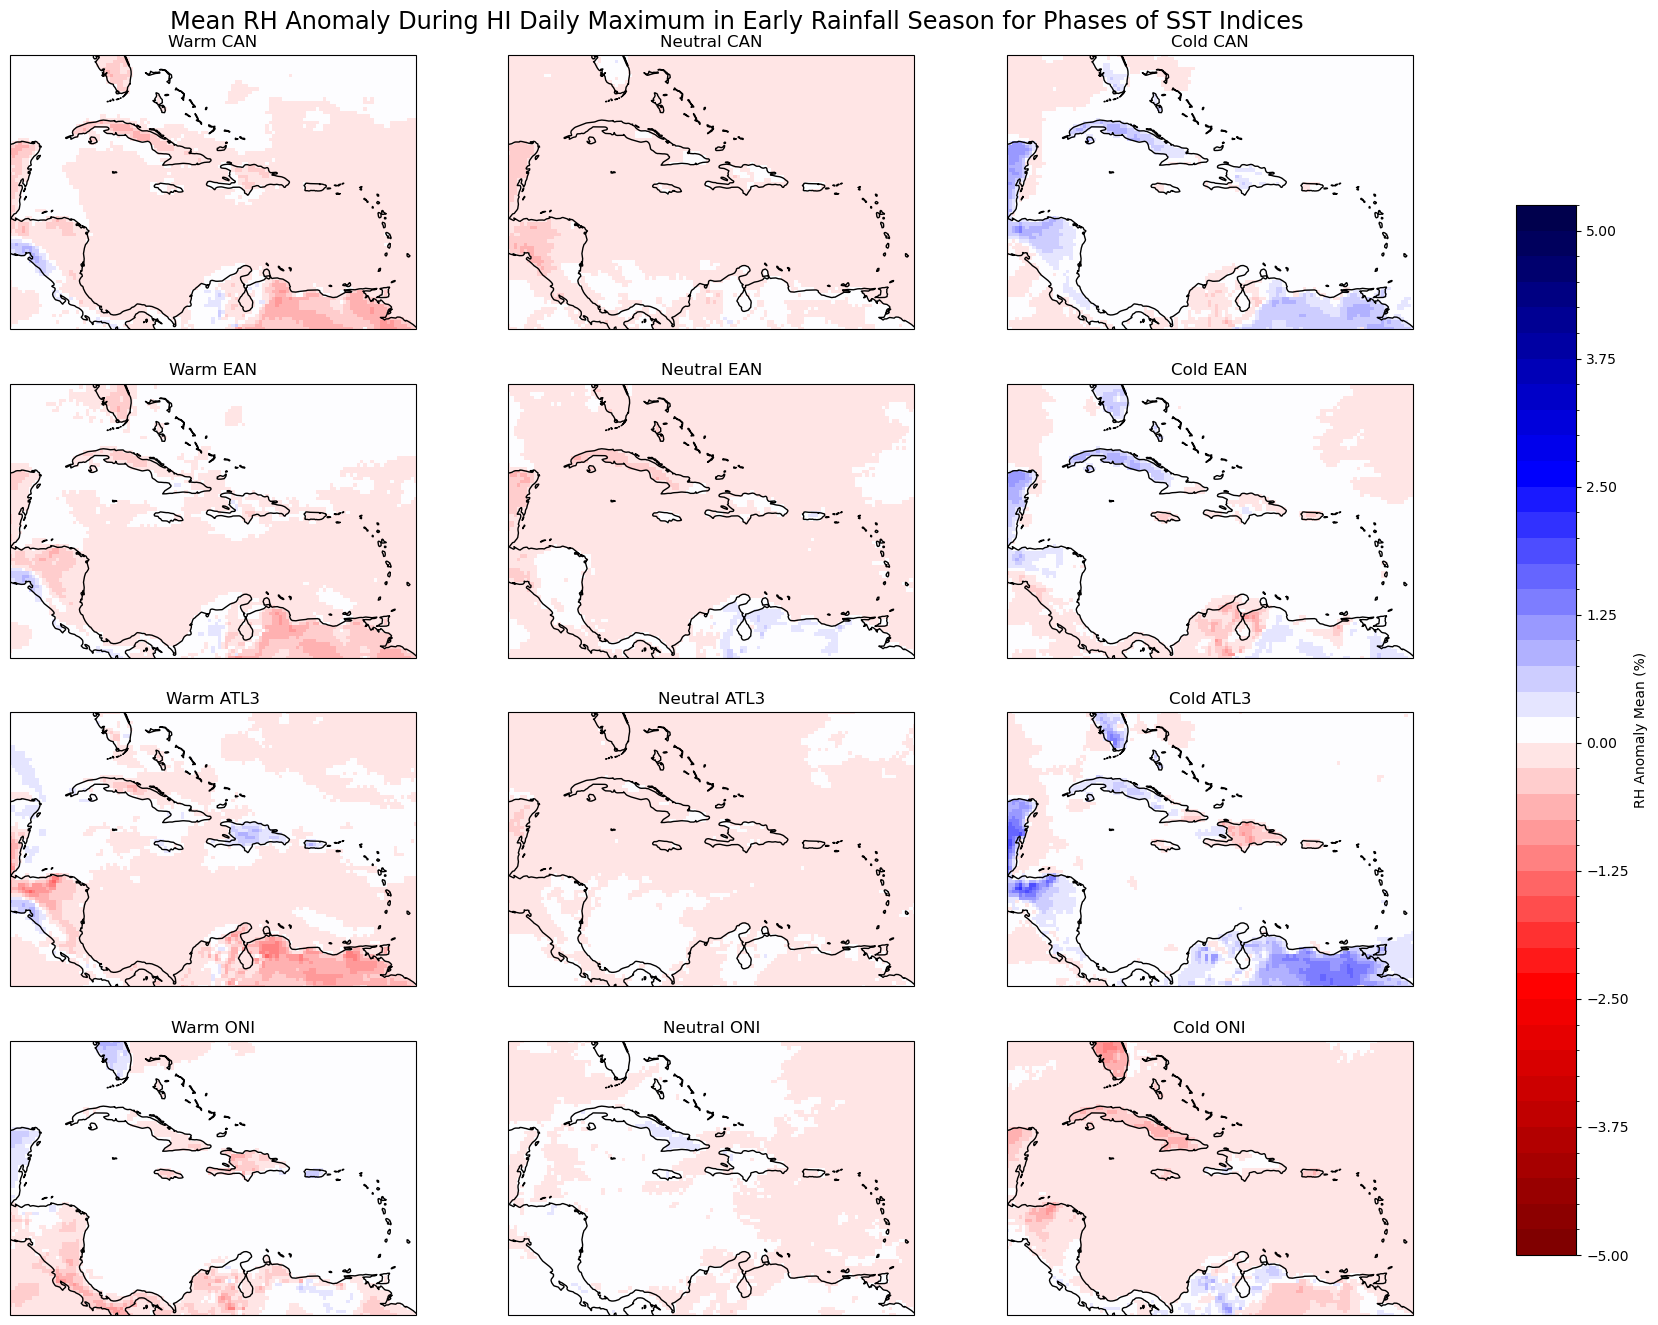

In [57]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, da in enumerate(ERS_RH_oan_me):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-5, 5.5, 0.25), transform=ccrs.PlateCarree(), colors='seismic_r')
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean RH Anomaly During HI Daily Maximum in Early Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()

### T

In [58]:
ERS_T_oan_me = []
for i in ERS_T_oan:
    ERS_T_oan_me.append(i.mean('time'))

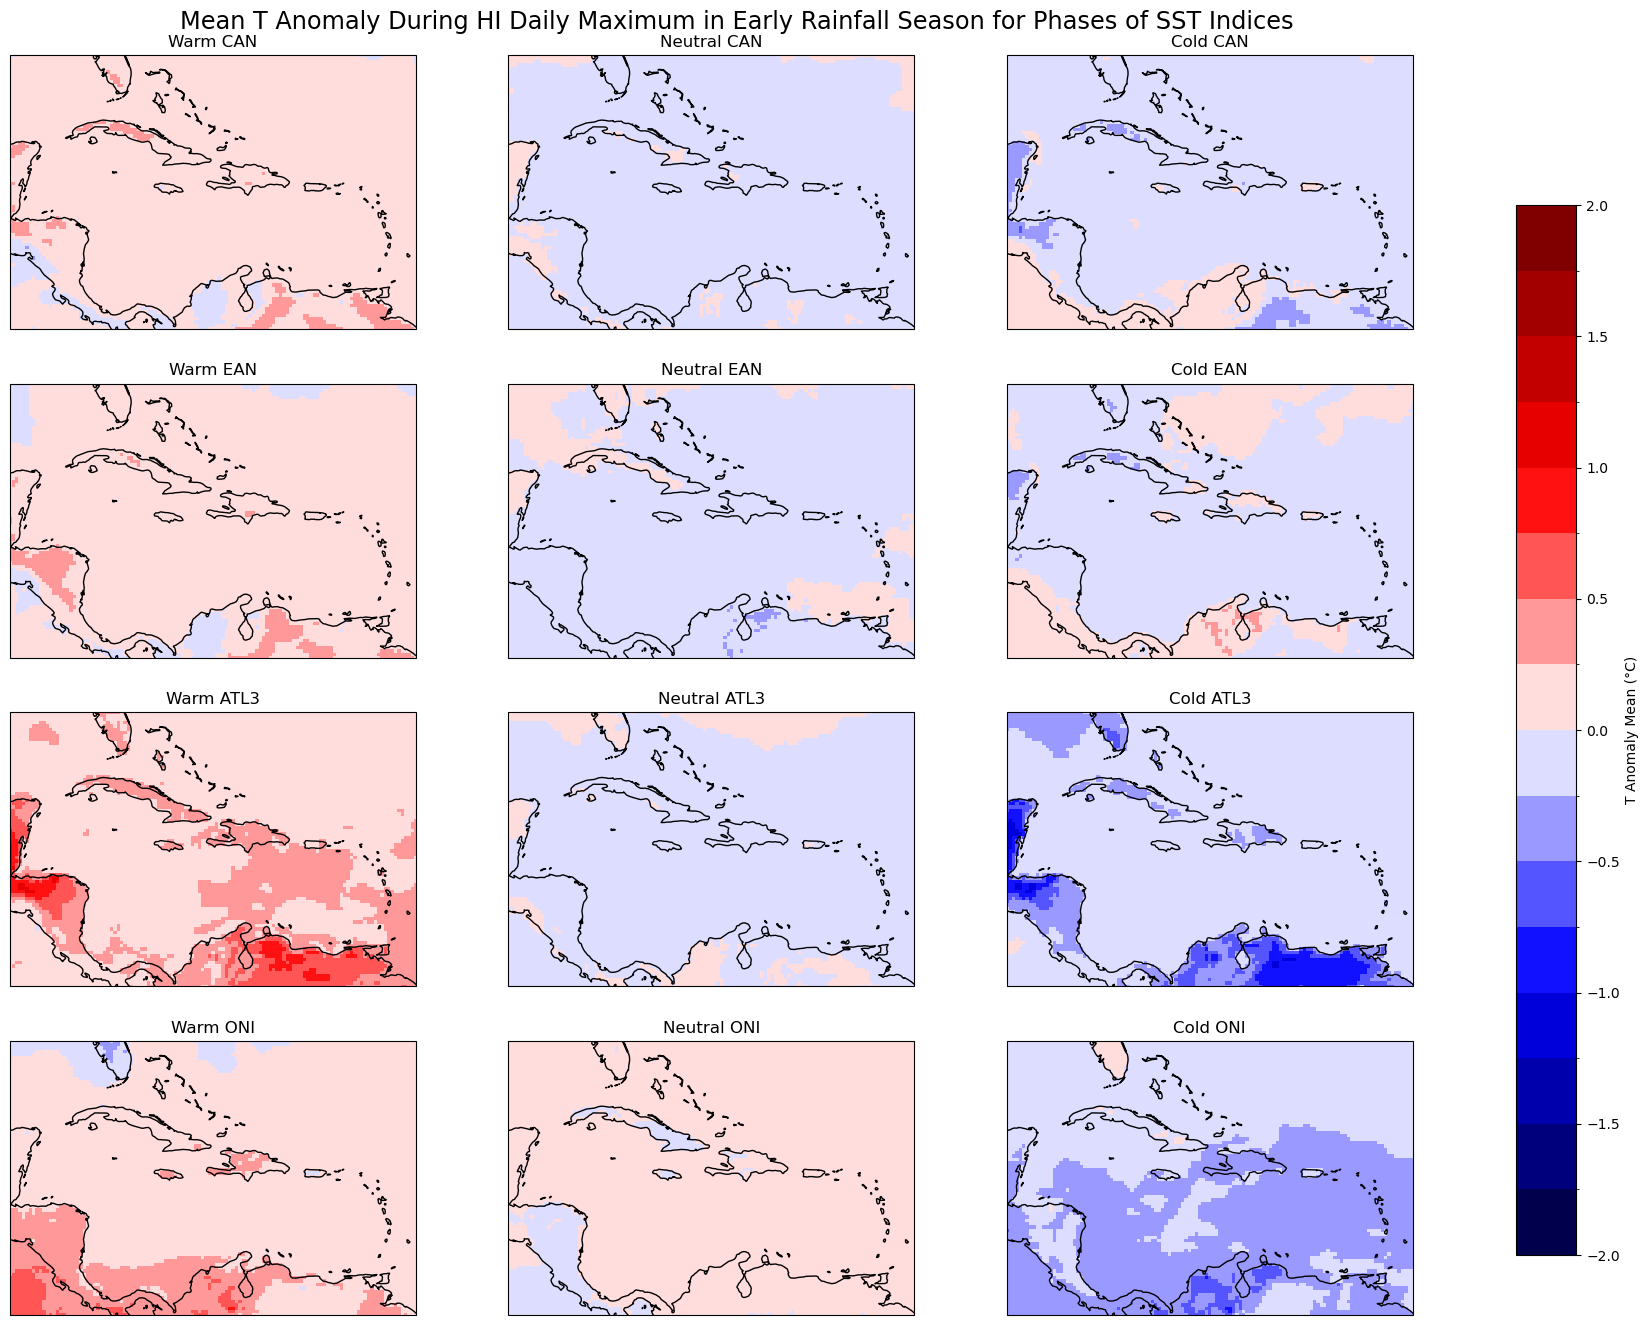

In [59]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, da in enumerate(ERS_T_oan_me):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-2, 2.25, 0.25), transform=ccrs.PlateCarree(), colors='seismic')
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='T Anomaly Mean (°C)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean T Anomaly During HI Daily Maximum in Early Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()

### MFD

In [60]:
ERS_MFD_oan_me = []
for i in ERS_MFD_oan:
    ERS_MFD_oan_me.append(i.mean('time'))

In [61]:
ERS_MFD_oan_me

[<xarray.DataArray 'Warm CAN' (latitude: 82, longitude: 121)> Size: 40kB
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(82, 121), dtype=float32)
 Coordinates:
   * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
 Attributes:
     long_name:   latitude
     short_name:  lat
     units:       degrees_north,
 <xarray.DataArray 'Neutral CAN' (latitude: 82, longitude: 121)> Size: 40kB
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..

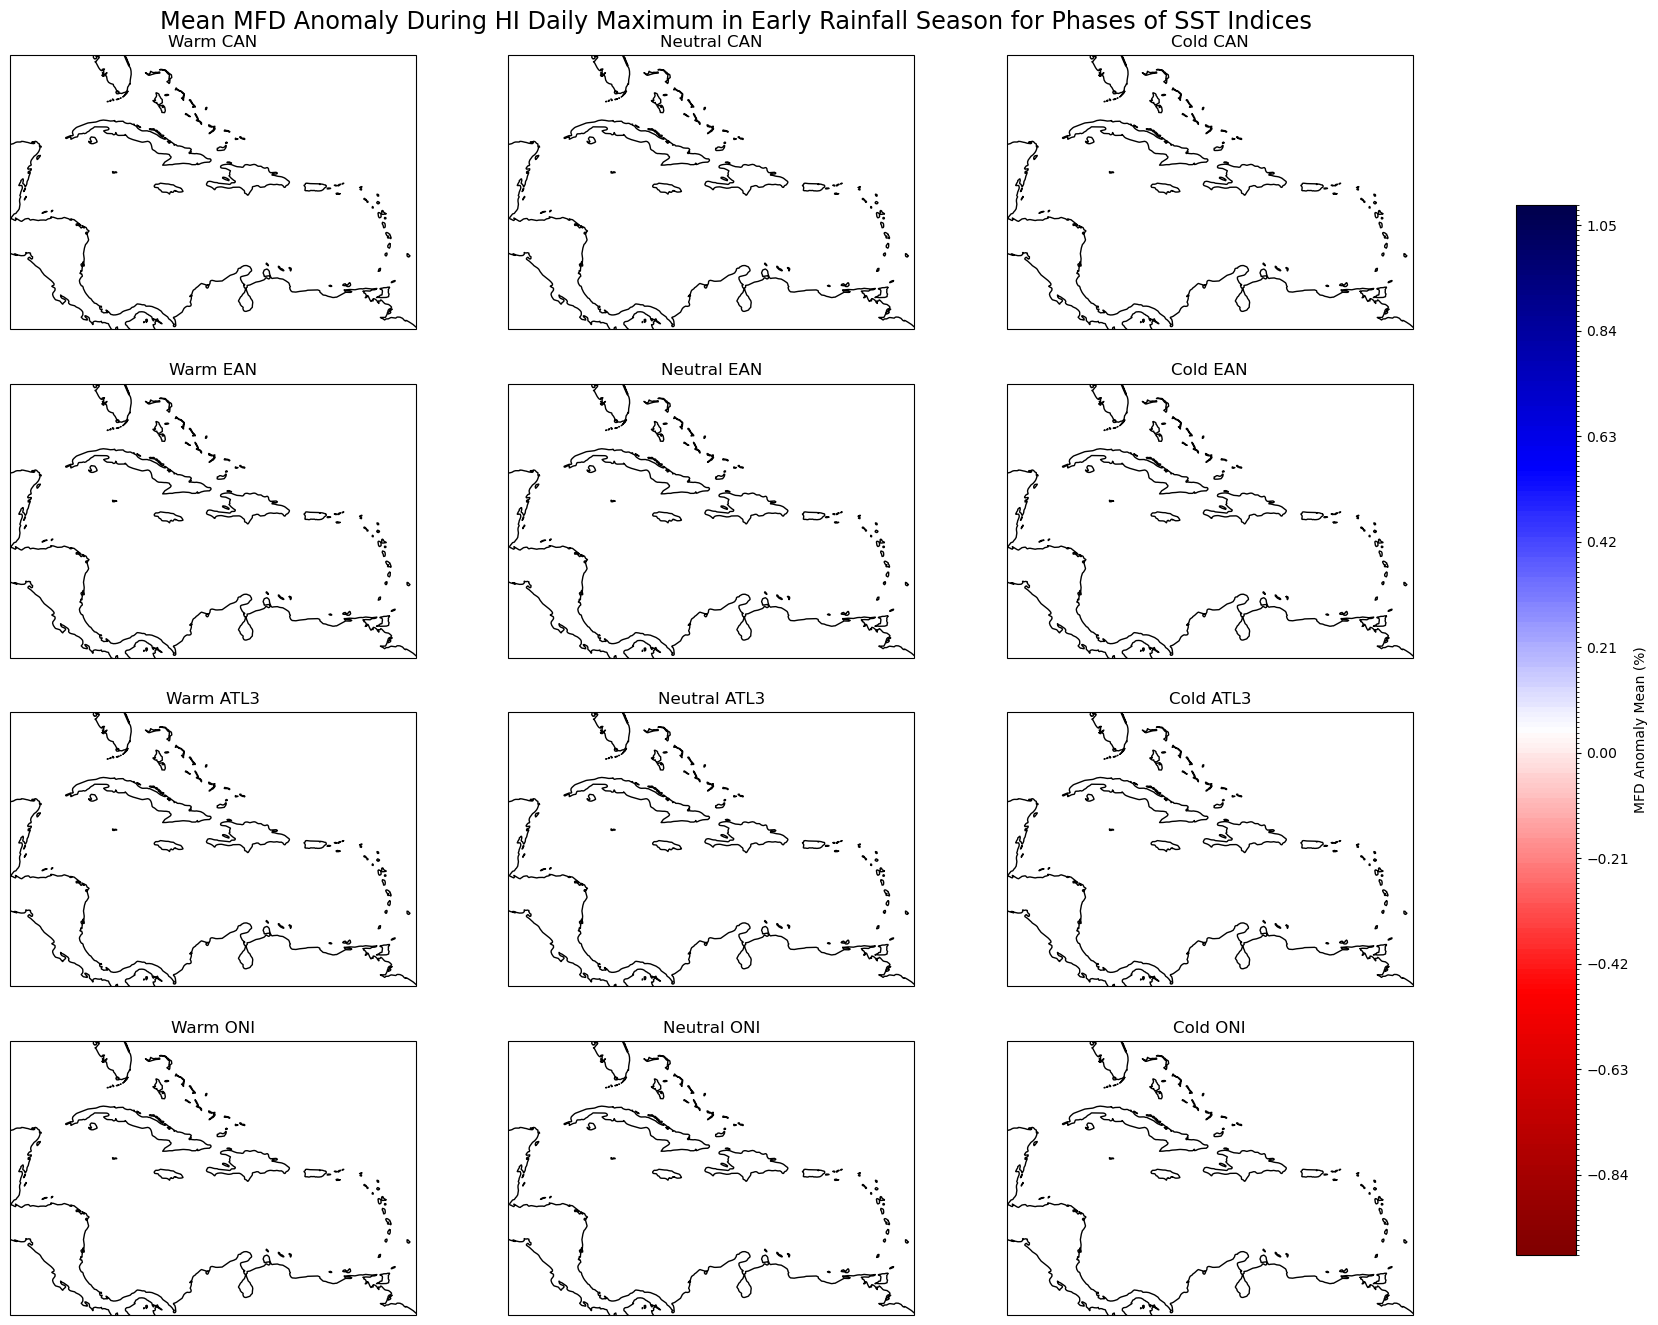

In [62]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, da in enumerate(ERS_MFD_oan_me):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-1, 1.1, 0.01), transform=ccrs.PlateCarree(), colors='seismic_r')
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='MFD Anomaly Mean (%)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean MFD Anomaly During HI Daily Maximum in Early Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()